# Law of Large Numbers & Central Limit Theorem
## A Simulation-Based Introduction

This notebook provides an interactive, visual exploration of two foundational results in probability theory:

1. **Law of Large Numbers (LLN)** — The sample mean converges to the population mean as the sample size grows.
2. **Central Limit Theorem (CLT)** — The distribution of the sample mean is approximately normal for large samples, *regardless* of the underlying distribution.

We use Monte Carlo simulations throughout to build intuition before (or after) seeing the formal proofs.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

plt.rcParams.update({
    "figure.figsize": (10, 5),
    "axes.titlesize": 14,
    "axes.labelsize": 12,
    "font.size": 11,
    "lines.linewidth": 2,
})

rng = np.random.default_rng(42)

---
# Part 1: Law of Large Numbers

**Theorem (Weak LLN).** Let $X_1, X_2, \ldots$ be i.i.d. random variables with finite mean $\mu$. Then the sample mean

$$\bar{X}_n = \frac{1}{n}\sum_{i=1}^{n} X_i$$

converges in probability to $\mu$: for every $\varepsilon > 0$,

$$\lim_{n\to\infty} P\!\left(|\bar{X}_n - \mu| > \varepsilon\right) = 0.$$

**Intuition:** As we collect more data, our running average settles down to the true mean. The next few cells let us *see* this happen.

## 1.1 Fair die rolls — watching the running mean converge

We roll a fair six-sided die repeatedly and plot the running average $\bar{X}_n$ as a function of $n$.  
The true mean is $\mu = 3.5$. Watch how different sample paths all converge to it.

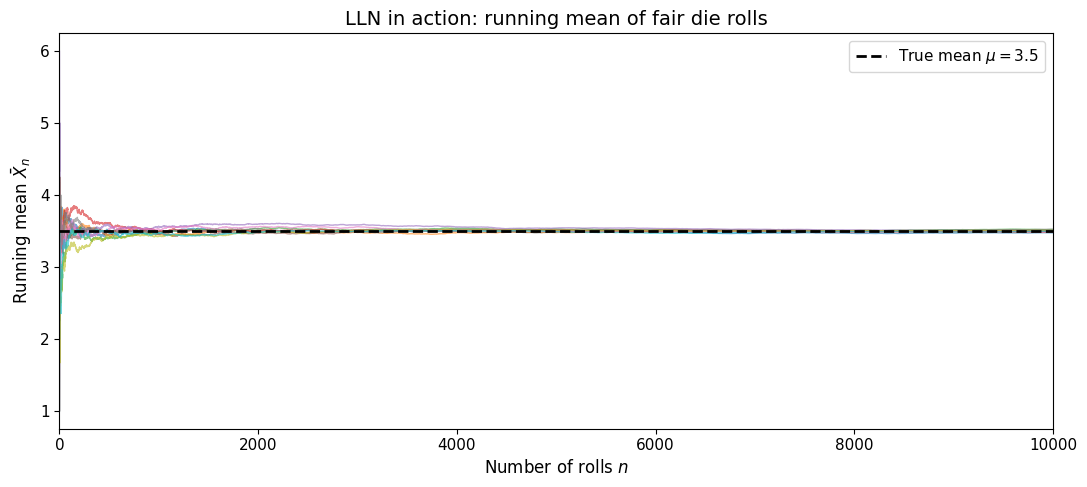

In [2]:
N = 10_000          # number of die rolls per path
n_paths = 10        # number of independent sample paths
true_mean = 3.5

fig, ax = plt.subplots(figsize=(11, 5))
for i in range(n_paths):
    rolls = rng.integers(1, 7, size=N)
    running_mean = np.cumsum(rolls) / np.arange(1, N + 1)
    ax.plot(running_mean, alpha=0.6, lw=1)

ax.axhline(true_mean, color="black", ls="--", lw=2, label=f"True mean $\\mu = {true_mean}$")
ax.set_xlabel("Number of rolls $n$")
ax.set_ylabel("Running mean $\\bar{X}_n$")
ax.set_title("LLN in action: running mean of fair die rolls")
ax.legend(loc="upper right")
ax.set_xlim(0, N)
plt.tight_layout()
plt.show()

## 1.2 LLN for different distributions

The LLN doesn't care about the shape of the distribution — only that the mean exists.  
Below we show convergence for three very different distributions side by side:
- **Exponential** ($\lambda = 1$, so $\mu = 1$) — skewed, heavy-tailed
- **Bernoulli** ($p = 0.3$, so $\mu = 0.3$) — discrete
- **Uniform** on $[0, 1]$ ($\mu = 0.5$) — symmetric, bounded

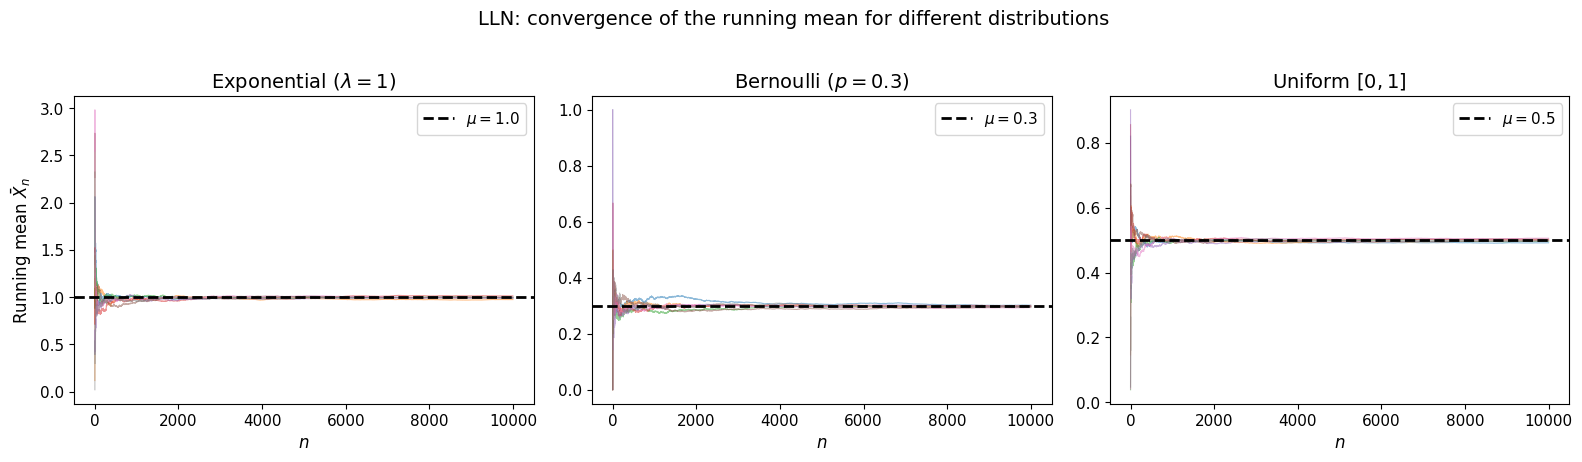

In [4]:
N = 10_000
n_paths = 8

distributions = [
    ("Exponential ($\\lambda=1$)", lambda n: rng.exponential(1.0, n), 1.0),
    ("Bernoulli ($p=0.3$)",        lambda n: rng.binomial(1, 0.3, n),  0.3),
    ("Uniform $[0,1]$",            lambda n: rng.uniform(0, 1, n),     0.5),
]

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5), sharey=False)

for ax, (name, sampler, mu) in zip(axes, distributions):
    for _ in range(n_paths):
        samples = sampler(N)
        running_mean = np.cumsum(samples) / np.arange(1, N + 1)
        ax.plot(running_mean, alpha=0.5, lw=0.8)
    ax.axhline(mu, color="black", ls="--", lw=2, label=f"$\\mu = {mu}$")
    ax.set_title(name)
    ax.set_xlabel("$n$")
    ax.legend(loc="upper right")

axes[0].set_ylabel("Running mean $\\bar{X}_n$")
fig.suptitle("LLN: convergence of the running mean for different distributions", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 1.3 Rate of convergence — the $1/\sqrt{n}$ envelope

By Chebyshev's inequality, $P(|\bar{X}_n - \mu| > \varepsilon) \le \sigma^2 / (n\varepsilon^2)$. The "width" of the fluctuations around $\mu$ shrinks like $\sigma / \sqrt{n}$.

Below we overlay a $\pm 2\sigma/\sqrt{n}$ band (≈ 95% of paths stay inside) on the die-roll example.

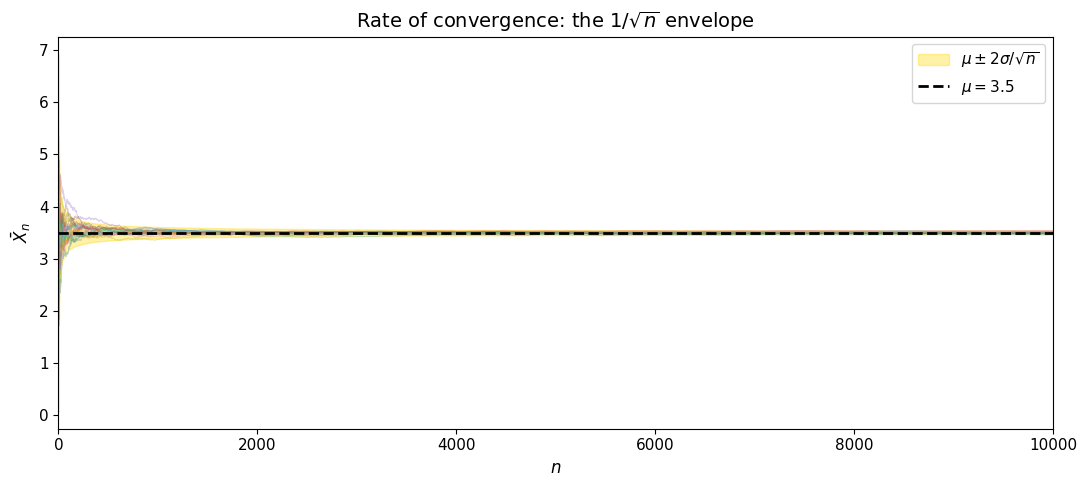

In [5]:
N = 10_000
sigma_die = np.sqrt(35 / 12)   # exact std dev of a fair die
ns = np.arange(1, N + 1)

fig, ax = plt.subplots(figsize=(11, 5))
for _ in range(20):
    rolls = rng.integers(1, 7, size=N)
    running_mean = np.cumsum(rolls) / ns
    ax.plot(running_mean, alpha=0.3, lw=0.7)

# ± 2 sigma / sqrt(n) envelope
envelope = 2 * sigma_die / np.sqrt(ns)
ax.fill_between(ns, 3.5 - envelope, 3.5 + envelope, color="gold", alpha=0.35,
                label=r"$\mu \pm 2\sigma/\sqrt{n}$")
ax.axhline(3.5, color="black", ls="--", lw=2, label="$\\mu = 3.5$")
ax.set_xlabel("$n$")
ax.set_ylabel("$\\bar{X}_n$")
ax.set_title("Rate of convergence: the $1/\\sqrt{n}$ envelope")
ax.legend(loc="upper right")
ax.set_xlim(0, N)
plt.tight_layout()
plt.show()

---
# Part 2: Central Limit Theorem

**Theorem (CLT).** Let $X_1, X_2, \ldots$ be i.i.d. with mean $\mu$ and finite variance $\sigma^2 > 0$. Then

$$\sqrt{n}\,\frac{\bar{X}_n - \mu}{\sigma} \;\xrightarrow{d}\; \mathcal{N}(0,\,1).$$

Equivalently, $\bar{X}_n$ is approximately $\mathcal{N}\!\left(\mu,\;\sigma^2/n\right)$ for large $n$.

**Key insight:** The CLT tells us not just that the sample mean converges (that's the LLN), but *what shape* the fluctuations around $\mu$ take — a **Gaussian bell curve**, no matter what the original distribution looks like.

### Simulation plan

For each of three distributions (Gaussian, Exponential, Uniform):
1. Draw $n = 100$ i.i.d. samples and compute $\bar{X}_{100}$.
2. Repeat this $100{,}000$ times to get the empirical distribution of $\bar{X}_{100}$.
3. Overlay the theoretical $\mathcal{N}(\mu, \sigma^2/n)$ density predicted by the CLT.

## 2.1 First, look at the *original* distributions

Before studying the sample mean, let's remind ourselves what each raw distribution looks like.  
Note how different they are — the exponential is heavily right-skewed, while the uniform is flat.

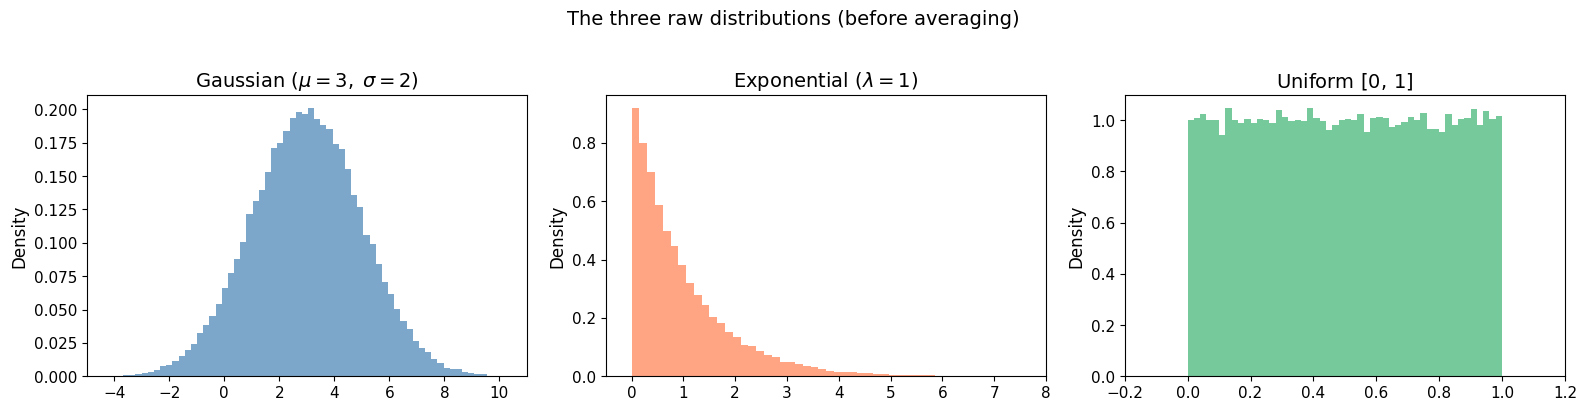

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Gaussian(3, 2^2)
data = rng.normal(3, 2, size=100_000)
axes[0].hist(data, bins=80, density=True, alpha=0.7, color="steelblue")
axes[0].set_title("Gaussian ($\\mu=3,\\; \\sigma=2$)")
axes[0].set_xlim(-5, 11)

# Exponential(lambda=1)
data = rng.exponential(1.0, size=100_000)
axes[1].hist(data, bins=80, density=True, alpha=0.7, color="coral")
axes[1].set_title("Exponential ($\\lambda=1$)")
axes[1].set_xlim(-0.5, 8)

# Uniform(0, 1)
data = rng.uniform(0, 1, size=100_000)
axes[2].hist(data, bins=50, density=True, alpha=0.7, color="mediumseagreen")
axes[2].set_title("Uniform $[0,\\,1]$")
axes[2].set_xlim(-0.2, 1.2)

for ax in axes:
    ax.set_ylabel("Density")

fig.suptitle("The three raw distributions (before averaging)", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 2.2 CLT in action — distribution of $\bar{X}_{100}$ from 100k simulations

Each histogram below shows the empirical distribution of $\bar{X}_{100}$ computed from **100,000 independent experiments**, each of size $n = 100$.

The red curve is the CLT prediction: $\mathcal{N}(\mu,\; \sigma^2 / n)$.

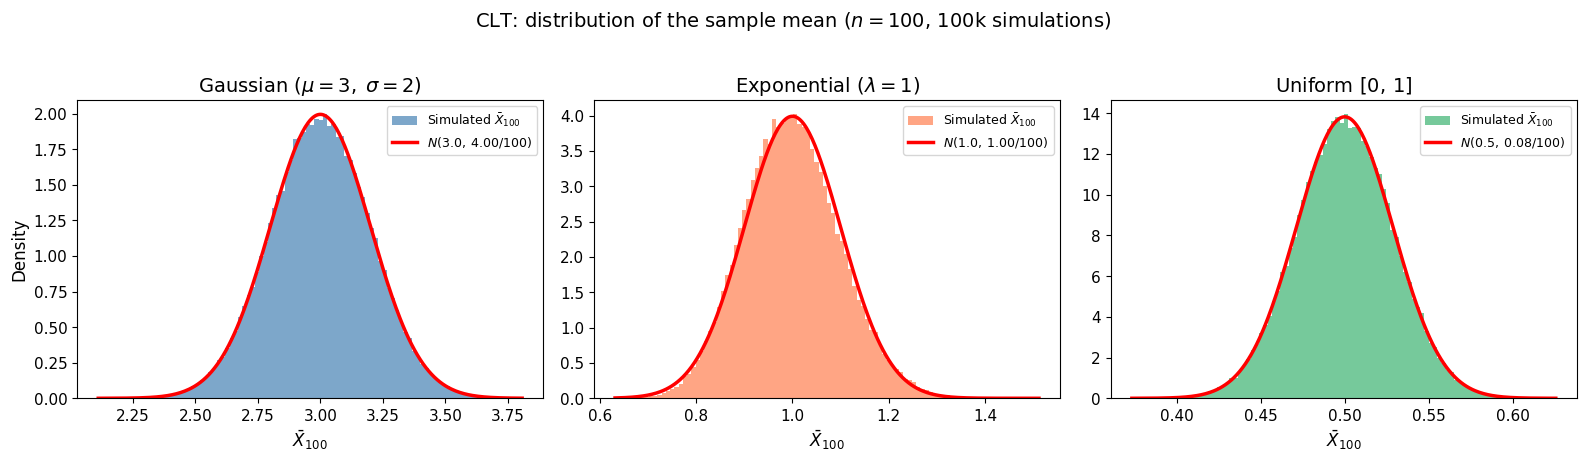

In [9]:
n = 100              # sample size for each experiment
N_sim = 100_000      # number of experiments

# Define distributions: (name, sampler, true_mean, true_std, color)
clt_distributions = [
    ("Gaussian ($\\mu=3,\\;\\sigma=2$)",
     lambda: rng.normal(3, 2, size=(N_sim, n)),
     3.0, 2.0, "steelblue"),
    ("Exponential ($\\lambda=1$)",
     lambda: rng.exponential(1.0, size=(N_sim, n)),
     1.0, 1.0, "coral"),
    ("Uniform $[0,\\,1]$",
     lambda: rng.uniform(0, 1, size=(N_sim, n)),
     0.5, 1/np.sqrt(12), "mediumseagreen"),
]

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

for ax, (name, sampler, mu, sigma, color) in zip(axes, clt_distributions):
    # Simulate 100k sample means
    sample_means = sampler().mean(axis=1)

    # Plot histogram
    ax.hist(sample_means, bins=100, density=True, alpha=0.7, color=color,
            label="Simulated $\\bar{X}_{100}$")

    # Overlay CLT normal density
    x = np.linspace(sample_means.min(), sample_means.max(), 300)
    clt_std = sigma / np.sqrt(n)
    ax.plot(x, stats.norm.pdf(x, mu, clt_std), "r-", lw=2.5,
            label=f"$N({mu},\\; {sigma**2:.2f}/{n})$")

    ax.set_title(name)
    ax.set_xlabel("$\\bar{X}_{100}$")
    ax.legend(fontsize=9)

axes[0].set_ylabel("Density")
fig.suptitle("CLT: distribution of the sample mean ($n=100$, 100k simulations)", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 2.3 How fast does the CLT "kick in"? — varying $n$

The CLT is an *asymptotic* result. For some distributions the normal approximation is excellent even for small $n$; for skewed distributions it takes longer.

Below we show the distribution of $\bar{X}_n$ for $n \in \{2,\; 5,\; 30,\; 100\}$, using the **Exponential($\lambda=1$)** distribution (the most skewed of our three) to stress-test convergence.

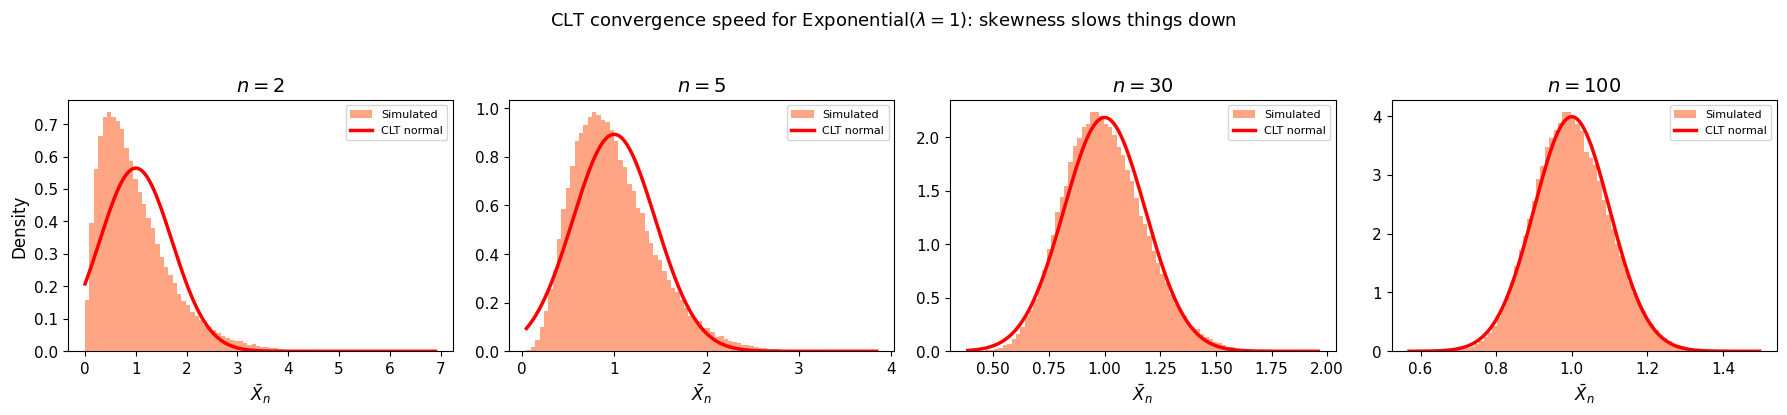

In [10]:
sample_sizes = [2, 5, 30, 100]
N_sim = 100_000
mu, sigma = 1.0, 1.0   # Exp(1) parameters

fig, axes = plt.subplots(1, 4, figsize=(18, 4))

for ax, n in zip(axes, sample_sizes):
    sample_means = rng.exponential(1.0, size=(N_sim, n)).mean(axis=1)
    ax.hist(sample_means, bins=80, density=True, alpha=0.7, color="coral",
            label="Simulated")

    x = np.linspace(sample_means.min(), sample_means.max(), 300)
    clt_std = sigma / np.sqrt(n)
    ax.plot(x, stats.norm.pdf(x, mu, clt_std), "r-", lw=2.5,
            label="CLT normal")

    ax.set_title(f"$n = {n}$")
    ax.set_xlabel("$\\bar{X}_n$")
    ax.legend(fontsize=8)

axes[0].set_ylabel("Density")
fig.suptitle("CLT convergence speed for Exponential($\\lambda=1$): skewness slows things down",
             fontsize=13, y=1.03)
plt.tight_layout()
plt.show()

## 2.4 QQ-plots — a quantitative check of normality

Histograms give a qualitative impression. **QQ-plots** give a sharper diagnostic: if $\bar{X}_n$ truly follows a normal distribution, the points should lie on the red diagonal line.

We compare $n = 5$ vs $n = 100$ for the exponential case to see how the approximation improves.

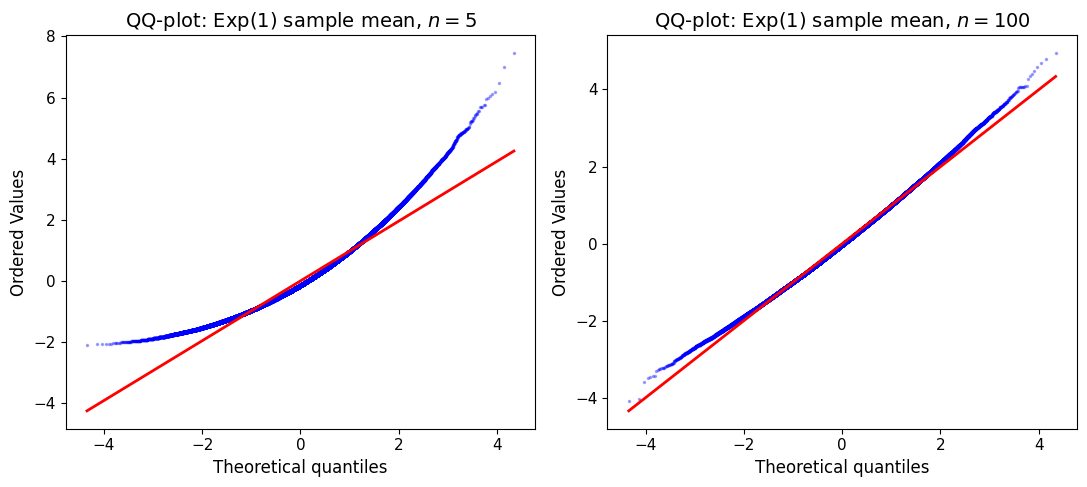

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(11, 5))

for ax, n in zip(axes, [5, 100]):
    sample_means = rng.exponential(1.0, size=(100_000, n)).mean(axis=1)
    # Standardize
    z = (sample_means - 1.0) / (1.0 / np.sqrt(n))
    stats.probplot(z, dist="norm", plot=ax)
    ax.set_title(f"QQ-plot: Exp(1) sample mean, $n = {n}$")
    ax.get_lines()[0].set(markersize=1.5, alpha=0.3)
    ax.get_lines()[1].set(color="red", lw=2)

plt.tight_layout()
plt.show()

## 2.5 The standardised version — all three collapse onto $\mathcal{N}(0,1)$

The CLT says the **standardised** sample mean $Z_n = \sqrt{n}(\bar{X}_n - \mu)/\sigma$ converges to $\mathcal{N}(0,1)$.

Let's standardise all three distributions and overlay them on a single plot. Despite their vastly different shapes, all three empirical distributions collapse onto the same standard normal.

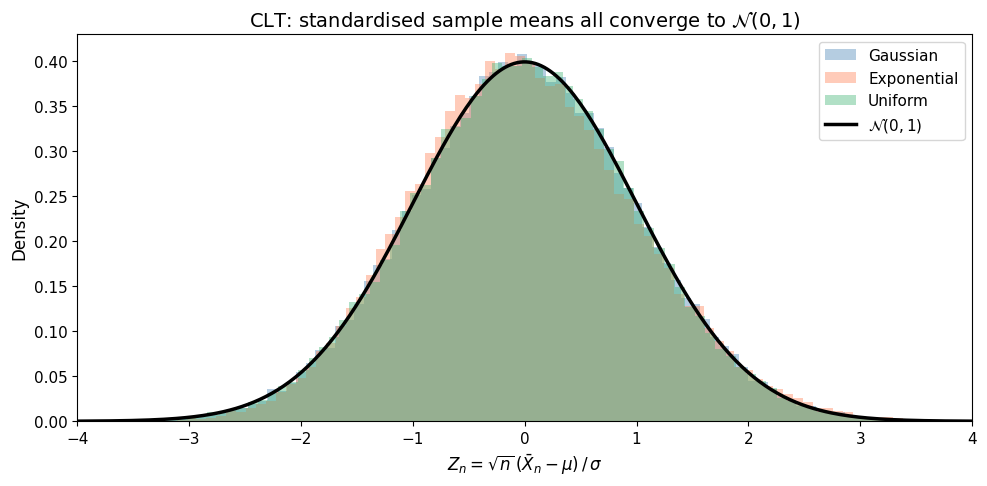

In [12]:
n = 100
N_sim = 100_000

fig, ax = plt.subplots(figsize=(10, 5))

configs = [
    ("Gaussian",     rng.normal(3, 2, size=(N_sim, n)),      3.0, 2.0,          "steelblue"),
    ("Exponential",  rng.exponential(1.0, size=(N_sim, n)),   1.0, 1.0,          "coral"),
    ("Uniform",      rng.uniform(0, 1, size=(N_sim, n)),      0.5, 1/np.sqrt(12),"mediumseagreen"),
]

for name, data, mu, sigma, color in configs:
    means = data.mean(axis=1)
    z = np.sqrt(n) * (means - mu) / sigma
    ax.hist(z, bins=100, density=True, alpha=0.4, color=color, label=name)

# Standard normal density
x = np.linspace(-4, 4, 300)
ax.plot(x, stats.norm.pdf(x), "k-", lw=2.5, label="$\\mathcal{N}(0,1)$")

ax.set_xlabel("$Z_n = \\sqrt{n}\\,(\\bar{X}_n - \\mu)\\,/\\,\\sigma$")
ax.set_ylabel("Density")
ax.set_title("CLT: standardised sample means all converge to $\\mathcal{N}(0,1)$")
ax.legend()
ax.set_xlim(-4, 4)
plt.tight_layout()
plt.show()

---
# Key Takeaways

| | **Law of Large Numbers** | **Central Limit Theorem** |
|---|---|---|
| **What it says** | $\bar{X}_n \to \mu$ as $n \to \infty$ | $\sqrt{n}(\bar{X}_n - \mu)/\sigma \xrightarrow{d} \mathcal{N}(0,1)$ |
| **Type of convergence** | In probability (weak LLN) or a.s. (strong LLN) | In distribution |
| **Requirements** | Finite mean $\mu$ | Finite mean $\mu$ **and** finite variance $\sigma^2$ |
| **Practical use** | Justifies using sample averages as estimates | Gives confidence intervals, hypothesis tests, etc. |
| **What we saw** | Running means stabilise around $\mu$ at rate $1/\sqrt{n}$ | Histograms of $\bar{X}_n$ look Gaussian regardless of the parent distribution |
